# Notebook 01 — Dataset exploration & Figure 1

**Purpose.**  This notebook characterises the ecDNA-FISH image resource and
produces every panel of Figure 1 in the paper.  It also introduces the
*anchor image* (`ncih2170_facs_fish_0723_low_her2_52`) that is reused as a
running example in all four notebooks.

**Audience.**  A reviewer or collaborator who wants to understand
what the dataset contains, how the benchmark subset was selected, and what
the gold-standard annotations look like — without needing to read any source
code first.

**What this notebook produces** (all files written to
`release/figures/notebook01/`):

| File | Description |
|------|-------------|
| `fig1_resource_composition_horizontal.svg` | Full resource vs benchmark subset, by cell line |
| `fig1_split_heatmap.svg` | Train / val / test breakdown by cell line |
| `fig1_count_distribution.svg` | Per-image ecDNA count histogram |
| `fig1_count_by_cell_line_boxstrip.svg` | Count distribution per cell line (box + strip) |
| `fig1_density_composition_heatmap.svg` | Density-bin composition heatmap |
| `fig1_anchor_rgb_gt_with_zoom.svg` | Anchor image: raw RGB and GS mask with zoom inset |
| `fig1_anchor_roi_masking_workflow.svg` | Four-step ROI masking illustration |
| `fig1_anchor_inset_clean.svg` | Zoomed inset: RGB, GS mask, and contour overlay |
| `fig1_anchor_composite.svg` | Main-paper anchor panel (RGB + ROI + zoomed GS inset) |

**No new quantitative results are computed.**  All numbers come from the
frozen manifests in `release/manifests/`.

---

### Setup — imports, paths, palettes, and helper functions

This cell defines every path and constant used downstream.  Run it once
before any other cell.

Key constants:
- `ANCHOR_UID` — the image used as a running example throughout all notebooks.
- `ANCHOR_INSET_BBOX` — the pixel rectangle `[x0=1247, y0=1225, x1=1458, y1=1353]`
  that highlights a cluster of ecDNA foci in the anchor image.
- `CELL_LINE_COLORS` — the Okabe-Ito five-class palette used in all figures.
- `DENSITY_ORDER` — the five count bins used throughout the benchmark evaluation.
```

In [1]:
# ── Setup ──────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.patches import Rectangle
import cv2
from IPython.display import display

# ── Repo root (one level above notebooks/) ─────────────────────────────────
REPO_ROOT = Path(os.getcwd()).parent          # adjust if needed
if not (REPO_ROOT / 'pyproject.toml').exists():
    REPO_ROOT = Path(os.getcwd())             # fallback: notebook IS in repo root
print(f'Repo root: {REPO_ROOT}')

sys.path.insert(0, str(REPO_ROOT))

# ── Paths ───────────────────────────────────────────────────────────────────
# Data root (Longleaf)
DATA_ROOT   = Path('/work/users/b/e/behnamie/ecDNA_Data/bioimage_archive')
RGB_DIR     = DATA_ROOT / 'rgb'
GT_DIR      = DATA_ROOT / 'gt_image'
ROI_DIR     = DATA_ROOT / 'roi_mask'

# Release manifests
MANIFESTS   = REPO_ROOT / 'release' / 'manifests'
SPLIT_DIR   = REPO_ROOT / 'release' / 'split_files'

# Full-resource metadata (internal CSV)
FULL_META_CSV = DATA_ROOT / 'metadata_internal.csv'

# Benchmark subset manifests
BENCH_META_CSV   = MANIFESTS / 'metadata.csv'
COUNTS_CSV       = MANIFESTS / 'counts_master.csv'

# Split files
TRAIN_CSV = SPLIT_DIR / 'train_ids.csv'
VAL_CSV   = SPLIT_DIR / 'val_ids.csv'
TEST_CSV  = SPLIT_DIR / 'test_ids.csv'

# Output directory
OUT_DIR = REPO_ROOT / 'release' / 'figures' / 'notebook01'
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'SVG output: {OUT_DIR}')

# ── Anchor image ────────────────────────────────────────────────────────────
ANCHOR_UID        = 'ncih2170_facs_fish_0723_low_her2_52'
ANCHOR_INSET_BBOX = [1247, 1225, 1458, 1353]   # x0, y0, x1, y1 (pixels, 2448×2048)

# ── Palette (locked per NOTEBOOKS_SUBMISSION_PLAN §9) ──────────────────────
CELL_LINE_COLORS = {
    'NCI-H2170': '#E69F00',
    'SUM159PT':  '#56B4E9',
    'SNU16':     '#009E73',
    'COLO320DM': '#CC79A7',
    'NCI-H716':  '#0072B2',
}
DENSITY_COLORS = {
    '0-9':     '#FFFFB2',
    '10-49':   '#FECC5C',
    '50-149':  '#FD8D3C',
    '150-299': '#F03B20',
    '300+':    '#BD0026',
}
DENSITY_ORDER  = ['0-9', '10-49', '50-149', '150-299', '300+']
CL_ORDER       = ['NCI-H2170', 'SUM159PT', 'SNU16', 'COLO320DM', 'NCI-H716']

# ── Publication style ───────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':       'sans-serif',
    'font.sans-serif':   ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size':         7,
    'axes.titlesize':    8,
    'axes.labelsize':    7,
    'xtick.labelsize':   6.2,
    'ytick.labelsize':   6.2,
    'legend.fontsize':   6.2,
    'figure.titlesize':  8,
    'axes.linewidth':    0.8,
    'lines.linewidth':   1.2,
    'lines.markersize':  4,
    'savefig.dpi':       300,
    'svg.fonttype':      'none',
    'pdf.fonttype':      42,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

def save_svg(fig, name):
    """Save figure as SVG (and PNG thumbnail) to OUT_DIR."""
    svg_path = OUT_DIR / f'{name}.svg'
    png_path = OUT_DIR / f'{name}.png'
    fig.savefig(svg_path, format='svg', bbox_inches='tight')
    fig.savefig(png_path, format='png', dpi=150, bbox_inches='tight')
    print(f'  Saved: {svg_path.name}')

print('Setup complete.')

Repo root: /proj/brunk_ecdna_cv_project/Poorya/ecdna-bench
SVG output: /proj/brunk_ecdna_cv_project/Poorya/ecdna-bench/release/figures/notebook01
Setup complete.


## §1 — Full image resource

The complete ecDNA-FISH collection contains **2,986 images** from five cell
lines imaged by FISH.  Only a subset of these — those for which a manual ROI
mask was drawn — form the **benchmark subset** used in all model evaluations.

This cell loads `metadata_internal.csv`, which covers the entire collection,
normalises the cell-line labels to their canonical display names (e.g.
`NCIH2170` → `NCI-H2170`), and builds the master summary table that all
downstream figures draw from.

**Why normalise labels?**  The raw metadata file uses compact identifiers
(no hyphens).  Without normalisation, `NCIH2170` and `NCI-H2170` would be
counted as different groups and the per-cell-line totals would be wrong.

The table printed at the end of the cell shows, for each cell line:
how many images are in the full resource, how many are in the benchmark
subset, and the train / val / test breakdown for benchmark images.


---

In [2]:
# Full-resource composition by cell line
# This cell intentionally normalizes cell-line names before counting.
# Without this, labels like "NCIH2170" and "NCI-H2170" appear as different groups.

# Load full-resource metadata
full_meta = pd.read_csv(FULL_META_CSV)


def canonical_cell_line(x):
    """Return the display label used throughout the paper/notebooks."""
    if pd.isna(x):
        return np.nan

    s = str(x).strip().upper()
    s_compact = s.replace('-', '').replace('_', '').replace(' ', '')

    mapping = {
        'NCIH2170':  'NCI-H2170',
        'SUM159PT':  'SUM159PT',
        'SNU16':     'SNU16',
        'COLO320DM': 'COLO320DM',
        'NCIH716':   'NCI-H716',
    }
    return mapping.get(s_compact, str(x).strip())


def as_bool_series(s):
    """Robustly interpret 0/1, True/False, and string booleans."""
    if s.dtype == bool:
        return s.fillna(False)

    # Try numeric first: 1 -> True, 0 -> False
    numeric = pd.to_numeric(s, errors='coerce')
    if numeric.notna().any():
        return numeric.fillna(0).astype(int).astype(bool)

    # Fallback for strings
    return (
        s.astype(str)
         .str.strip()
         .str.lower()
         .isin(['true', '1', 'yes', 'y'])
    )


full_meta = full_meta.copy()
full_meta['cell_line_display'] = full_meta['cell_line'].apply(canonical_cell_line)

if 'in_benchmark' in full_meta.columns:
    full_meta['in_benchmark_bool'] = as_bool_series(full_meta['in_benchmark'])
else:
    full_meta['in_benchmark_bool'] = full_meta['roi_mask_filename'].notna()

# Basic audit: show raw labels so hidden naming issues are visible
raw_label_audit = (
    full_meta
    .groupby(['cell_line', 'cell_line_display'], dropna=False)
    .size()
    .reset_index(name='n_images')
    .sort_values(['cell_line_display', 'cell_line'])
)

print('Raw cell-line labels found in metadata_internal.csv:')
display(raw_label_audit)

# Main summary table
summary_rows = []
for cl in CL_ORDER:
    sub = full_meta[full_meta['cell_line_display'] == cl]
    bench = sub[sub['in_benchmark_bool']]

    row = {
        'cell_line': cl,
        'full_resource_images': len(sub),
        'benchmark_images': len(bench),
        'non_benchmark_images': len(sub) - len(bench),
        'has_roi_mask_filename': int(sub['roi_mask_filename'].notna().sum()) if 'roi_mask_filename' in sub.columns else np.nan,
        'train': int((bench['split'] == 'train').sum()) if 'split' in bench.columns else np.nan,
        'val': int((bench['split'] == 'val').sum()) if 'split' in bench.columns else np.nan,
        'test': int((bench['split'] == 'test').sum()) if 'split' in bench.columns else np.nan,
    }
    summary_rows.append(row)

full_resource_summary = pd.DataFrame(summary_rows)

# Add total row
total_row = {
    'cell_line': 'Total',
    'full_resource_images': int(full_resource_summary['full_resource_images'].sum()),
    'benchmark_images': int(full_resource_summary['benchmark_images'].sum()),
    'non_benchmark_images': int(full_resource_summary['non_benchmark_images'].sum()),
    'has_roi_mask_filename': int(full_resource_summary['has_roi_mask_filename'].sum())
        if full_resource_summary['has_roi_mask_filename'].notna().any() else np.nan,
    'train': int(full_resource_summary['train'].sum()) if full_resource_summary['train'].notna().any() else np.nan,
    'val': int(full_resource_summary['val'].sum()) if full_resource_summary['val'].notna().any() else np.nan,
    'test': int(full_resource_summary['test'].sum()) if full_resource_summary['test'].notna().any() else np.nan,
}
full_resource_summary = pd.concat(
    [full_resource_summary, pd.DataFrame([total_row])],
    ignore_index=True
)

print('\nFull resource and benchmark subset by cell line:')
display(full_resource_summary)

# Compact sanity checks
n_full = len(full_meta)
n_benchmark = int(full_meta['in_benchmark_bool'].sum())
n_missing_cell_line = int(full_meta['cell_line_display'].isna().sum())
unknown_labels = sorted(
    set(full_meta['cell_line_display'].dropna()) - set(CL_ORDER)
)

print('\nSanity checks:')
print(f'  Full resource rows:       {n_full:,}')
print(f'  Benchmark subset rows:    {n_benchmark:,}')
print(f'  Missing cell-line labels: {n_missing_cell_line:,}')
print(f'  Unknown normalized labels: {unknown_labels if unknown_labels else "none"}')

# Save source data for transparency
source_csv = OUT_DIR / 'source_full_resource_summary.csv'
full_resource_summary.to_csv(source_csv, index=False)
print(f'\nSaved source table: {source_csv.name}')

Raw cell-line labels found in metadata_internal.csv:


,cell_line,cell_line_display,n_images
0,COLO320DM,COLO320DM,225
1,NCIH2170,NCI-H2170,1891
2,NCIH716,NCI-H716,139
3,SNU16,SNU16,273
4,SUM159PT,SUM159PT,458



Full resource and benchmark subset by cell line:


,cell_line,full_resource_images,benchmark_images,non_benchmark_images,has_roi_mask_filename,train,val,test
0,NCI-H2170,1891,888,1003,888,621,133,134
1,SUM159PT,458,0,458,0,0,0,0
2,SNU16,273,123,150,123,86,18,19
3,COLO320DM,225,64,161,64,44,9,11
4,NCI-H716,139,70,69,70,49,10,11
5,Total,2986,1145,1841,1145,800,170,175



Sanity checks:
  Full resource rows:       2,986
  Benchmark subset rows:    1,145
  Missing cell-line labels: 0
  Unknown normalized labels: none

Saved source table: source_full_resource_summary.csv


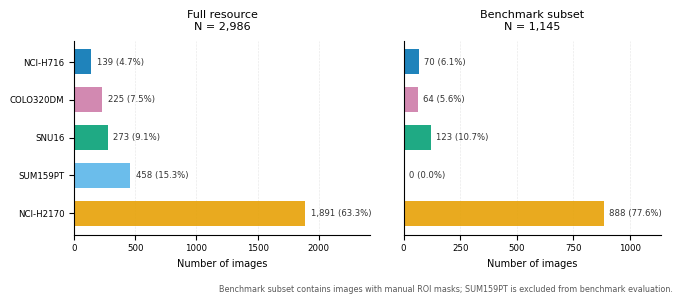

  Saved SVG: fig1_resource_composition_horizontal.svg
  Saved PNG: fig1_resource_composition_horizontal.png
  Source CSV saved: fig1_resource_composition_horizontal.csv


In [3]:
# ── Fig 1A option A: Full resource vs benchmark subset — horizontal bars ─────
# Clarity-first version for notebook / manuscript review.

# Avoid duplicate rendering in Jupyter:
# use display(fig) only, not display(fig) + plt.show().

plot_df = (
    full_resource_summary[full_resource_summary['cell_line'] != 'Total']
    .copy()
)

plot_df['cell_line'] = pd.Categorical(
    plot_df['cell_line'],
    categories=CL_ORDER,
    ordered=True
)
plot_df = plot_df.sort_values('cell_line')

plot_df['full_resource_images'] = plot_df['full_resource_images'].astype(int)
plot_df['benchmark_images'] = plot_df['benchmark_images'].astype(int)

n_full = int(plot_df['full_resource_images'].sum())
n_bench = int(plot_df['benchmark_images'].sum())

plot_df['pct_full'] = 100 * plot_df['full_resource_images'] / n_full
plot_df['pct_benchmark'] = np.where(
    n_bench > 0,
    100 * plot_df['benchmark_images'] / n_bench,
    np.nan
)

# Save source data
source_cols = [
    'cell_line',
    'full_resource_images',
    'benchmark_images',
    'non_benchmark_images',
    'pct_full',
    'pct_benchmark',
    'train',
    'val',
    'test',
]
source_df = plot_df[source_cols].copy()
source_csv = OUT_DIR / 'fig1_resource_composition_horizontal.csv'
source_df.to_csv(source_csv, index=False)

# Figure
fig, axes = plt.subplots(
    ncols=2,
    figsize=(6.8, 2.8),
    sharey=True,
    gridspec_kw={'width_ratios': [1.15, 1.0]}
)

panels = [
    {
        'ax': axes[0],
        'value_col': 'full_resource_images',
        'pct_col': 'pct_full',
        'title': f'Full resource\nN = {n_full:,}',
        'xlabel': 'Number of images',
    },
    {
        'ax': axes[1],
        'value_col': 'benchmark_images',
        'pct_col': 'pct_benchmark',
        'title': f'Benchmark subset\nN = {n_bench:,}',
        'xlabel': 'Number of images',
    },
]

ypos = np.arange(len(plot_df))

for panel in panels:
    ax = panel['ax']
    values = plot_df[panel['value_col']].astype(int).values
    pcts = plot_df[panel['pct_col']].values
    colors = [CELL_LINE_COLORS[cl] for cl in plot_df['cell_line']]

    bars = ax.barh(
        ypos,
        values,
        color=colors,
        edgecolor='none',
        height=0.66,
        alpha=0.88,
    )

    ax.set_title(panel['title'], pad=8)
    ax.set_xlabel(panel['xlabel'])
    ax.set_yticks(ypos)
    ax.set_yticklabels(plot_df['cell_line'])
    ax.invert_yaxis()

    ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=5, integer=True))
    ax.grid(axis='x', linestyle='--', linewidth=0.45, alpha=0.30)
    ax.set_axisbelow(True)

    xmax = max(values.max(), 1)
    ax.set_xlim(0, xmax * 1.28)

    for i, (n, pct) in enumerate(zip(values, pcts)):
        label = f'{n:,}'
        if np.isfinite(pct):
            label += f' ({pct:.1f}%)'

        ax.text(
            n + xmax * 0.025,
            i,
            label,
            va='center',
            ha='left',
            fontsize=6.1,
            color='0.20'
        )

# Remove repeated y-axis labels on right panel
axes[1].tick_params(axis='y', left=False, labelleft=False)

# Subtle note under figure
fig.text(
    0.99, -0.02,
    'Benchmark subset contains images with manual ROI masks; SUM159PT is excluded from benchmark evaluation.',
    ha='right',
    va='top',
    fontsize=5.8,
    color='0.35'
)

fig.tight_layout(w_pad=2.2)

# Inline display once
display(fig)

# Save both SVG and PNG
svg_path = OUT_DIR / 'fig1_resource_composition_horizontal.svg'
png_path = OUT_DIR / 'fig1_resource_composition_horizontal.png'
fig.savefig(svg_path, format='svg', bbox_inches='tight')
fig.savefig(png_path, format='png', dpi=300, bbox_inches='tight')

print(f'  Saved SVG: {svg_path.name}')
print(f'  Saved PNG: {png_path.name}')
print(f'  Source CSV saved: {source_csv.name}')

plt.close(fig)

### Figure 1 panel — Full resource vs benchmark subset (horizontal bars)

Side-by-side horizontal bar charts comparing the full collection (N = 2,986)
with the benchmark subset (N = 1,145), broken down by cell line.

Key observations visible in the figure:
- **NCI-H2170** dominates both the full resource and the benchmark subset
  (~63 % and ~78 % respectively) because it is the primary cell line for
  ecDNA research in this study.
- **SUM159PT** is present in the full resource (458 images) but is **excluded
  from the benchmark** because it lacks manual ROI masks.
- The remaining three cell lines (SNU16, COLO320DM, NCI-H716) are smaller
  but well-represented relative to their total availability.

Saved as: `fig1_resource_composition_horizontal.svg`
Source data: `source_full_resource_summary.csv`

---

In [4]:
# ── Build clean benchmark dataframe with authoritative GS counts ─────────────
# This replaces the older merge cell and the older per-cell-line summary cell.
#
# Important:
# counts_master.csv is treated as authoritative for ecDNA_gt.
# Any ecDNA_gt column already present in metadata.csv is ignored to avoid
# silently summarizing a stale count column.

bench_meta = pd.read_csv(BENCH_META_CSV)
counts_df  = pd.read_csv(COUNTS_CSV)

# Load split files
train_ids = pd.read_csv(TRAIN_CSV)['unique_id'].astype(str).tolist()
val_ids   = pd.read_csv(VAL_CSV)['unique_id'].astype(str).tolist()
test_ids  = pd.read_csv(TEST_CSV)['unique_id'].astype(str).tolist()

split_map = {uid: 'train' for uid in train_ids}
split_map.update({uid: 'val' for uid in val_ids})
split_map.update({uid: 'test' for uid in test_ids})

# Standardize UID dtype
bench_meta = bench_meta.copy()
counts_df = counts_df.copy()
bench_meta['unique_id'] = bench_meta['unique_id'].astype(str)
counts_df['unique_id'] = counts_df['unique_id'].astype(str)

# Normalize cell-line labels
bench_meta['cell_line_display'] = bench_meta['cell_line'].apply(canonical_cell_line)

# Drop any pre-existing count columns from metadata so counts_master.csv is authoritative
stale_count_cols = [
    c for c in bench_meta.columns
    if c == 'ecDNA_gt' or c.startswith('ecDNA_gt_')
]
bench_base = bench_meta.drop(columns=stale_count_cols, errors='ignore').copy()

# Merge authoritative GS counts
required_count_cols = ['unique_id', 'ecDNA_gt']
missing_count_cols = [c for c in required_count_cols if c not in counts_df.columns]
if missing_count_cols:
    raise ValueError(f'counts_master.csv is missing required columns: {missing_count_cols}')

bench = bench_base.merge(
    counts_df[['unique_id', 'ecDNA_gt']],
    on='unique_id',
    how='left',
    validate='one_to_one'
)

# Use split in metadata if present, but verify/fill from official split files
bench['split_from_files'] = bench['unique_id'].map(split_map)

if 'split' not in bench.columns:
    bench['split'] = bench['split_from_files']
else:
    bench['split'] = bench['split'].fillna(bench['split_from_files'])

# Clean split label formatting
bench['split'] = bench['split'].astype(str).str.lower().str.strip()

# QC flags
bench['has_authoritative_count'] = bench['ecDNA_gt'].notna()
bench['has_official_split'] = bench['split_from_files'].notna()
bench['split_matches_files'] = bench['split'].eq(bench['split_from_files'])

# Basic validation
n_bench = len(bench)
n_missing_counts = int((~bench['has_authoritative_count']).sum())
n_missing_splits = int((~bench['has_official_split']).sum())
n_split_mismatch = int((~bench['split_matches_files']).sum())

print('Benchmark dataframe built from metadata.csv + counts_master.csv')
print(f'  Rows:                  {n_bench:,}')
print(f'  Missing ecDNA_gt:       {n_missing_counts:,}')
print(f'  Missing official split: {n_missing_splits:,}')
print(f'  Split mismatches:       {n_split_mismatch:,}')

print('\nOfficial split counts:')
display(
    bench['split']
    .value_counts()
    .reindex(['train', 'val', 'test'])
    .fillna(0)
    .astype(int)
    .rename_axis('split')
    .reset_index(name='n_images')
)

# Descriptive benchmark summary by cell line
benchmark_count_summary = (
    bench
    .groupby('cell_line_display', observed=False)
    .agg(
        n_images=('unique_id', 'count'),
        train=('split', lambda s: int((s == 'train').sum())),
        val=('split', lambda s: int((s == 'val').sum())),
        test=('split', lambda s: int((s == 'test').sum())),
        mean_count=('ecDNA_gt', 'mean'),
        median_count=('ecDNA_gt', 'median'),
        q25_count=('ecDNA_gt', lambda x: x.quantile(0.25)),
        q75_count=('ecDNA_gt', lambda x: x.quantile(0.75)),
        min_count=('ecDNA_gt', 'min'),
        max_count=('ecDNA_gt', 'max'),
    )
    .reindex([cl for cl in CL_ORDER if cl != 'SUM159PT'])
    .reset_index()
    .rename(columns={'cell_line_display': 'cell_line'})
)

# Add total row
total_row = pd.DataFrame([{
    'cell_line': 'Total',
    'n_images': int(bench['unique_id'].count()),
    'train': int((bench['split'] == 'train').sum()),
    'val': int((bench['split'] == 'val').sum()),
    'test': int((bench['split'] == 'test').sum()),
    'mean_count': bench['ecDNA_gt'].mean(),
    'median_count': bench['ecDNA_gt'].median(),
    'q25_count': bench['ecDNA_gt'].quantile(0.25),
    'q75_count': bench['ecDNA_gt'].quantile(0.75),
    'min_count': bench['ecDNA_gt'].min(),
    'max_count': bench['ecDNA_gt'].max(),
}])

benchmark_count_summary = pd.concat(
    [benchmark_count_summary, total_row],
    ignore_index=True
)

# Clean formatting for display
display_summary = benchmark_count_summary.copy()
count_cols = ['mean_count', 'median_count', 'q25_count', 'q75_count', 'min_count', 'max_count']
display_summary[count_cols] = display_summary[count_cols].round(1)

print('\nBenchmark subset — per-cell-line ecDNA count summary:')
display(display_summary)

# Save source table
summary_csv = OUT_DIR / 'source_benchmark_count_summary.csv'
benchmark_count_summary.to_csv(summary_csv, index=False)
print(f'\nSaved source table: {summary_csv.name}')

Benchmark dataframe built from metadata.csv + counts_master.csv
  Rows:                  1,145
  Missing ecDNA_gt:       0
  Missing official split: 0
  Split mismatches:       0

Official split counts:


,split,n_images
0,train,800
1,val,170
2,test,175



Benchmark subset — per-cell-line ecDNA count summary:


,cell_line,n_images,train,val,test,mean_count,median_count,q25_count,q75_count,min_count,max_count
0,NCI-H2170,888,621,133,134,199.2,153.0,94.0,250.2,9,1687
1,SNU16,123,86,18,19,283.5,241.0,175.5,333.0,57,1231
2,COLO320DM,64,44,9,11,46.0,42.5,23.8,59.0,1,144
3,NCI-H716,70,49,10,11,190.6,174.0,135.0,212.5,71,468
4,Total,1145,800,170,175,199.2,159.0,94.0,254.0,1,1687



Saved source table: source_benchmark_count_summary.csv


## §2 — Benchmark subset

The benchmark subset consists of the 1,145 images that have:
1. A manually drawn ROI mask (delineating the metaphase spread), and
2. A rendered gold-standard ecDNA mask (one 7×7 diamond per annotated point).

This cell merges two sources:
- `metadata.csv` — image-level metadata (cell line, file paths).
- `counts_master.csv` — the **authoritative** per-image ecDNA count
  (`ecDNA_gt`), defined as the number of 8-connected components (min area
  3 px) in the rendered GS mask.

> **Important:** any `ecDNA_gt` column already present in `metadata.csv`
> is dropped and replaced with the value from `counts_master.csv`.
> `counts_master.csv` is the single source of truth for all counts.

The cell also cross-checks the `split` assignment against the three
fixed split files (`train_ids.csv`, `val_ids.csv`, `test_ids.csv`) and
raises an error if any mismatches are found.

The summary table printed at the end shows, per cell line, the image
count, split breakdown, and descriptive statistics of `ecDNA_gt`.


---

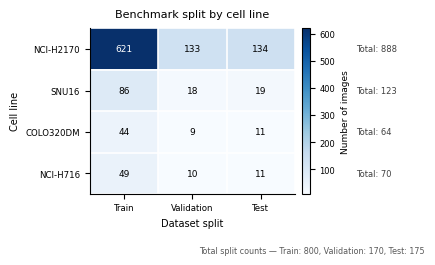

  Saved SVG: fig1_split_heatmap.svg
  Saved PNG: fig1_split_heatmap.png
  Source CSV saved: fig1_split_heatmap.csv


In [5]:
# ── Fig 1Cb: Benchmark split by cell line — heatmap with exact counts ─────────

split_order = ['train', 'val', 'test']
split_labels = ['Train', 'Validation', 'Test']
row_order = [cl for cl in CL_ORDER if cl != 'SUM159PT']

# Build split matrix
split_mat = (
    bench
    .groupby(['cell_line_display', 'split'])
    .size()
    .unstack(fill_value=0)
    .reindex(index=row_order)
    .reindex(columns=split_order, fill_value=0)
)

# Save source data
source_df = split_mat.reset_index().rename(columns={'cell_line_display': 'cell_line'})
source_csv = OUT_DIR / 'fig1_split_heatmap.csv'
source_df.to_csv(source_csv, index=False)

# Totals
row_totals = split_mat.sum(axis=1)
col_totals = split_mat.sum(axis=0)

# Plot
fig, ax = plt.subplots(figsize=(4.3, 2.4))

vals = split_mat.values.astype(float)
im = ax.imshow(vals, aspect='auto', cmap='Blues')

# Ticks and labels
ax.set_xticks(np.arange(len(split_labels)))
ax.set_xticklabels(split_labels)
ax.set_yticks(np.arange(len(row_order)))
ax.set_yticklabels(row_order)

ax.set_title('Benchmark split by cell line', pad=8)
ax.set_xlabel('Dataset split')
ax.set_ylabel('Cell line')

# Minor gridlines to create table-like look
ax.set_xticks(np.arange(-.5, len(split_labels), 1), minor=True)
ax.set_yticks(np.arange(-.5, len(row_order), 1), minor=True)
ax.grid(which='minor', color='white', linestyle='-', linewidth=1.2)
ax.tick_params(which='minor', bottom=False, left=False)

# Annotate counts in each cell
vmax = vals.max() if vals.size else 1
for i in range(vals.shape[0]):
    for j in range(vals.shape[1]):
        value = int(vals[i, j])
        text_color = 'white' if vals[i, j] > vmax * 0.45 else 'black'
        ax.text(
            j, i, f'{value}',
            ha='center', va='center',
            fontsize=6.5,
            color=text_color
        )

# Optional colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.05, pad=0.03)
cbar.set_label('Number of images', fontsize=6.5)
cbar.ax.tick_params(labelsize=6)

# Add row totals to the right of the matrix
for i, total in enumerate(row_totals):
    ax.text(
        len(split_labels) - 0.02 + 0.42, i,
        f'Total: {int(total)}',
        ha='left', va='center',
        fontsize=6.0,
        color='0.25',
        clip_on=False
    )

# Add total split counts as note
total_note = (
    f"Total split counts — Train: {int(col_totals['train'])}, "
    f"Validation: {int(col_totals['val'])}, "
    f"Test: {int(col_totals['test'])}"
)
fig.text(
    0.99, -0.03,
    total_note,
    ha='right', va='top',
    fontsize=5.8,
    color='0.35'
)

fig.tight_layout()

display(fig)

svg_path = OUT_DIR / 'fig1_split_heatmap.svg'
png_path = OUT_DIR / 'fig1_split_heatmap.png'
fig.savefig(svg_path, format='svg', bbox_inches='tight')
fig.savefig(png_path, format='png', dpi=300, bbox_inches='tight')

print(f'  Saved SVG: {svg_path.name}')
print(f'  Saved PNG: {png_path.name}')
print(f'  Source CSV saved: {source_csv.name}')

plt.close(fig)

### Figure 1 panel — Benchmark split by cell line (heatmap)

A heatmap showing how the 1,145 benchmark images are distributed across
the three fixed splits (Train / Validation / Test) and four benchmark cell
lines.

The split is **stratified by cell line**: each row shows that the cell-line
proportions are approximately consistent across train, val, and test.
The colour scale shows absolute image counts; exact numbers are annotated
in each cell.

Total split counts:
- **Train:** 800 images (used for model fitting and BO optimisation)
- **Validation:** 170 images (used for model selection and BO probe selection)
- **Test:** 175 images (held out; all reported paper metrics come from here)

Saved as: `fig1_split_heatmap.svg`

---

## §3 — Gold-standard ecDNA count distribution

Each benchmark image has a scalar gold-standard ecDNA count (`ecDNA_gt`):
the number of 8-connected components (minimum area 3 px) in the rendered
GS mask.  This is the quantity every model in the benchmark is evaluated
against.

In [6]:
# ── §3: Gold-standard ecDNA count distribution setup ─────────────────────────
# ecDNA_gt is the benchmark gold-standard object count per image.
# Count bins follow the evaluation configuration:
# 0-9, 10-49, 50-149, 150-299, 300+

# Defensive checks
required_cols = ['unique_id', 'cell_line_display', 'split', 'ecDNA_gt']
missing_cols = [c for c in required_cols if c not in bench.columns]
if missing_cols:
    raise ValueError(f'bench is missing required columns: {missing_cols}')

bench = bench.copy()
bench['ecDNA_gt'] = pd.to_numeric(bench['ecDNA_gt'], errors='coerce')

if bench['ecDNA_gt'].isna().any():
    n_missing = int(bench['ecDNA_gt'].isna().sum())
    raise ValueError(f'{n_missing} benchmark rows have missing ecDNA_gt values.')

bench['ecDNA_gt'] = bench['ecDNA_gt'].astype(int)

# Assign count bins robustly
density_edges = [-np.inf, 9, 49, 149, 299, np.inf]
bench['density_bin'] = pd.cut(
    bench['ecDNA_gt'],
    bins=density_edges,
    labels=DENSITY_ORDER,
    right=True
)

bench['density_bin'] = pd.Categorical(
    bench['density_bin'],
    categories=DENSITY_ORDER,
    ordered=True
)

# Global density-bin summary
density_summary = (
    bench
    .groupby('density_bin', observed=False)
    .agg(
        n_images=('unique_id', 'count'),
        pct_benchmark=('unique_id', lambda x: 100 * len(x) / len(bench)),
        mean_count=('ecDNA_gt', 'mean'),
        median_count=('ecDNA_gt', 'median'),
        min_count=('ecDNA_gt', 'min'),
        max_count=('ecDNA_gt', 'max'),
    )
    .reindex(DENSITY_ORDER)
    .reset_index()
)

density_summary_display = density_summary.copy()
for col in ['pct_benchmark', 'mean_count', 'median_count']:
    density_summary_display[col] = density_summary_display[col].round(1)

print('Benchmark ecDNA density-bin summary:')
display(density_summary_display)

print('\nGlobal ecDNA count summary:')
global_count_summary = pd.DataFrame([{
    'n_images': len(bench),
    'mean_count': bench['ecDNA_gt'].mean(),
    'median_count': bench['ecDNA_gt'].median(),
    'q25_count': bench['ecDNA_gt'].quantile(0.25),
    'q75_count': bench['ecDNA_gt'].quantile(0.75),
    'min_count': bench['ecDNA_gt'].min(),
    'max_count': bench['ecDNA_gt'].max(),
}])
display(global_count_summary.round(1))

# Save source tables
density_summary.to_csv(OUT_DIR / 'source_density_bin_summary.csv', index=False)
global_count_summary.to_csv(OUT_DIR / 'source_global_count_summary.csv', index=False)

print('  Saved: source_density_bin_summary.csv')
print('  Saved: source_global_count_summary.csv')

Benchmark ecDNA density-bin summary:


,density_bin,n_images,pct_benchmark,mean_count,median_count,min_count,max_count
0,0-9,7,0.6,4.7,4.0,1,9
1,10-49,79,6.9,33.9,35.0,10,49
2,50-149,450,39.3,99.3,99.0,50,149
3,150-299,403,35.2,213.5,210.0,150,299
4,300+,206,18.0,459.3,405.0,300,1687



Global ecDNA count summary:


,n_images,mean_count,median_count,q25_count,q75_count,min_count,max_count
0,1145,199.2,159.0,94.0,254.0,1,1687


  Saved: source_density_bin_summary.csv
  Saved: source_global_count_summary.csv




### Count bins

To enable stratified analysis, images are grouped into five **count bins**
based on `ecDNA_gt`:

| Bin | Range | N in benchmark | % |
|-----|-------|----------------|---|
| 0-9 | 1 – 9 | 7 | 0.6 % |
| 10-49 | 10 – 49 | 79 | 6.9 % |
| 50-149 | 50 – 149 | 450 | 39.3 % |
| 150-299 | 150 – 299 | 403 | 35.2 % |
| 300+ | ≥ 300 | 206 | 18.0 % |

These bins are used throughout the benchmark evaluation (e.g. F1 vs density
bin plots in Notebooks 03 and 04).

This cell assigns count bins and prints the global count summary
(N = 1,145, median = 159, mean = 199, max = 1,687).


---


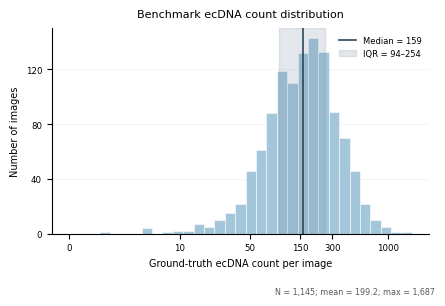

  Saved SVG: fig1_count_distribution.svg
  Saved PNG: fig1_count_distribution.png
  Source CSV saved: fig1_count_distribution.csv


In [7]:
# ── Fig 1D: Gold-standard ecDNA count distribution ────────────────────────────
# Histogram shown on log10(count + 1) scale so zero-count images remain valid.

counts_vals = bench['ecDNA_gt'].dropna().astype(int)
log_counts = np.log10(counts_vals + 1)

median_count = counts_vals.median()
q25_count = counts_vals.quantile(0.25)
q75_count = counts_vals.quantile(0.75)
mean_count = counts_vals.mean()
max_count = counts_vals.max()

# Source data
hist_source = bench[['unique_id', 'cell_line_display', 'split', 'ecDNA_gt', 'density_bin']].copy()
hist_source = hist_source.rename(columns={'cell_line_display': 'cell_line'})
source_csv = OUT_DIR / 'fig1_count_distribution.csv'
hist_source.to_csv(source_csv, index=False)

fig, ax = plt.subplots(figsize=(4.4, 2.8))

# Bins in transformed space
bins = np.linspace(0, np.log10(max_count + 1), 34)

# Softer/lighter bar color
ax.hist(
    log_counts,
    bins=bins,
    color='#9EC3D8',          # lighter, softer blue
    edgecolor='white',
    linewidth=0.4,
    alpha=0.95
)

# Median and IQR
ax.axvline(
    np.log10(median_count + 1),
    color='#2F4858',
    linestyle='-',
    linewidth=1.2,
    label=f'Median = {median_count:.0f}'
)

ax.axvspan(
    np.log10(q25_count + 1),
    np.log10(q75_count + 1),
    color='#6D8299',
    alpha=0.18,
    label=f'IQR = {q25_count:.0f}–{q75_count:.0f}'
)

# X ticks shown as original counts
tick_counts = [0, 10, 50, 150, 300, 1000]
tick_counts = [t for t in tick_counts if t <= max_count]
tick_positions = [np.log10(t + 1) for t in tick_counts]

ax.set_xticks(tick_positions)
ax.set_xticklabels([str(t) for t in tick_counts])

ax.set_xlabel('Gold-standard ecDNA count per image')
ax.set_ylabel('Number of images')
ax.set_title('Benchmark ecDNA count distribution', pad=8)

ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=5, integer=True))
ax.grid(axis='y', linestyle='--', linewidth=0.45, alpha=0.30)
ax.set_axisbelow(True)

ax.legend(frameon=False, fontsize=6.0, loc='upper right')

# Compact summary note
note = (
    f'N = {len(counts_vals):,}; '
    f'mean = {mean_count:.1f}; '
    f'max = {max_count:,}'
)
fig.text(
    0.99, -0.03,
    note,
    ha='right',
    va='top',
    fontsize=5.8,
    color='0.35'
)

fig.tight_layout()

display(fig)

svg_path = OUT_DIR / 'fig1_count_distribution.svg'
png_path = OUT_DIR / 'fig1_count_distribution.png'
fig.savefig(svg_path, format='svg', bbox_inches='tight')
fig.savefig(png_path, format='png', dpi=300, bbox_inches='tight')

print(f'  Saved SVG: {svg_path.name}')
print(f'  Saved PNG: {png_path.name}')
print(f'  Source CSV saved: {source_csv.name}')

plt.close(fig)

### Figure 1 panel — ecDNA count distribution (histogram)

Log-axis histogram of `ecDNA_gt` across all 1,145 benchmark images.
The distribution spans nearly three orders of magnitude (1 – 1,687 per
image), with a median of **159** and an IQR of **94 – 254**.

The grey shaded region marks the IQR; the vertical line marks the median.
The log axis is necessary because a small number of very high-density images
(> 500) would otherwise compress the bulk of the distribution into the
left margin.

Saved as: `fig1_count_distribution.svg`
Source data: `source_density_bin_summary.csv`, `source_global_count_summary.csv`


---

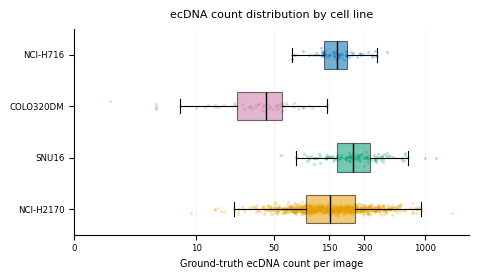

  Saved SVG: fig1_count_by_cell_line_boxstrip.svg
  Saved PNG: fig1_count_by_cell_line_boxstrip.png
  Source CSV saved: fig1_count_by_cell_line_boxstrip.csv


In [8]:
# ── Exploratory: ecDNA count distribution by cell line ───────────────────────
# This is useful for notebook exploration. It may be better as a supplement
# than as a main Figure 1 panel.

row_order = [cl for cl in CL_ORDER if cl != 'SUM159PT']

plot_data = [
    bench.loc[bench['cell_line_display'] == cl, 'ecDNA_gt'].dropna().astype(int).values
    for cl in row_order
]

fig, ax = plt.subplots(figsize=(4.8, 2.8))

# Boxplot on log10(count + 1) scale
log_plot_data = [np.log10(x + 1) for x in plot_data]

bp = ax.boxplot(
    log_plot_data,
    vert=False,
    patch_artist=True,
    widths=0.55,
    showfliers=False,
    medianprops={'color': 'black', 'linewidth': 1.0},
    boxprops={'linewidth': 0.8},
    whiskerprops={'linewidth': 0.8},
    capprops={'linewidth': 0.8},
)

for patch, cl in zip(bp['boxes'], row_order):
    patch.set_facecolor(CELL_LINE_COLORS[cl])
    patch.set_alpha(0.55)

# Add jittered individual points
rng = np.random.default_rng(42)
for i, (cl, values) in enumerate(zip(row_order, plot_data), start=1):
    y = rng.normal(i, 0.045, size=len(values))
    x = np.log10(values + 1)
    ax.scatter(
        x,
        y,
        s=5,
        color=CELL_LINE_COLORS[cl],
        alpha=0.28,
        linewidths=0,
        rasterized=True
    )

ax.set_yticks(np.arange(1, len(row_order) + 1))
ax.set_yticklabels(row_order)

# X ticks as original counts
max_count = int(bench['ecDNA_gt'].max())
tick_counts = [0, 10, 50, 150, 300, 1000]
tick_counts = [t for t in tick_counts if t <= max_count]
ax.set_xticks([np.log10(t + 1) for t in tick_counts])
ax.set_xticklabels([str(t) for t in tick_counts])

ax.set_xlabel('Gold-standard ecDNA count per image')
ax.set_title('ecDNA count distribution by cell line', pad=8)

ax.grid(axis='x', linestyle='--', linewidth=0.45, alpha=0.30)
ax.set_axisbelow(True)

fig.tight_layout()

display(fig)

svg_path = OUT_DIR / 'fig1_count_by_cell_line_boxstrip.svg'
png_path = OUT_DIR / 'fig1_count_by_cell_line_boxstrip.png'
fig.savefig(svg_path, format='svg', bbox_inches='tight')
fig.savefig(png_path, format='png', dpi=300, bbox_inches='tight')

source_csv = OUT_DIR / 'fig1_count_by_cell_line_boxstrip.csv'
bench[['unique_id', 'cell_line_display', 'split', 'ecDNA_gt', 'density_bin']].rename(
    columns={'cell_line_display': 'cell_line'}
).to_csv(source_csv, index=False)

print(f'  Saved SVG: {svg_path.name}')
print(f'  Saved PNG: {png_path.name}')
print(f'  Source CSV saved: {source_csv.name}')

plt.close(fig)

### Exploratory panel — ecDNA count distribution by cell line

This panel is a box-and-strip plot showing the `ecDNA_gt` distribution
separately for each benchmark cell line (log-scaled x-axis).

Key observations:
- **COLO320DM** is a low-count cell line (median ≈ 43, max 144), which
  explains why it is the easiest for all models.
- **SNU16** has the highest median count (≈ 241), creating a challenging
  high-density regime.
- **NCI-H2170** has the widest range (9 – 1,687) because it is by far
  the largest group and spans all count bins.
- **NCI-H716** sits at intermediate density (median ≈ 174).

This panel may appear as a supplementary figure or be used for editorial
explanation.  It is not strictly needed for the main Figure 1 panels.

Saved as: `fig1_count_by_cell_line_boxstrip.svg`
Source data: `source_benchmark_count_summary.csv`


---

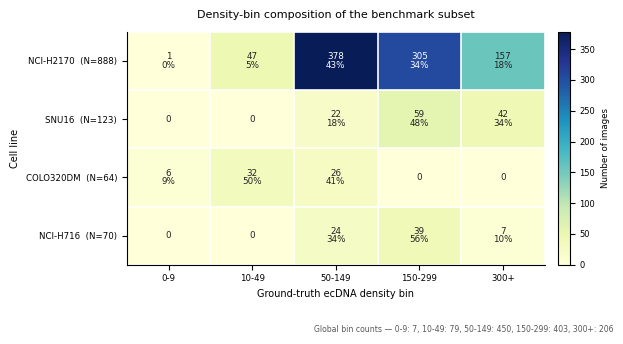

  Saved SVG: fig1_density_composition_heatmap.svg
  Saved PNG: fig1_density_composition_heatmap.png
  Source CSV saved: fig1_density_composition_counts.csv
  Source CSV saved: fig1_density_composition_percent.csv


In [9]:
# ── Fig 1E: Density-bin composition by cell line — cleaner heatmap ───────────
# Cleaner version:
# - row totals moved into y-axis labels
# - no extra text on the right
# - slightly larger figure for readability

row_order = [cl for cl in CL_ORDER if cl != 'SUM159PT']

density_mat = (
    bench
    .groupby(['cell_line_display', 'density_bin'], observed=False)
    .size()
    .unstack(fill_value=0)
    .reindex(index=row_order)
    .reindex(columns=DENSITY_ORDER, fill_value=0)
)

row_totals = density_mat.sum(axis=1)
density_pct = density_mat.div(row_totals, axis=0) * 100

# Save source data
source_counts = density_mat.reset_index().rename(columns={'cell_line_display': 'cell_line'})
source_counts.to_csv(OUT_DIR / 'fig1_density_composition_counts.csv', index=False)

source_pct = density_pct.reset_index().rename(columns={'cell_line_display': 'cell_line'})
source_pct.to_csv(OUT_DIR / 'fig1_density_composition_percent.csv', index=False)

# Y-axis labels with row totals included
y_labels = [f'{cl}  (N={int(row_totals.loc[cl])})' for cl in row_order]

# Plot
fig, ax = plt.subplots(figsize=(6.2, 3.1))

vals = density_mat.values.astype(float)
im = ax.imshow(vals, aspect='auto', cmap='YlGnBu')

ax.set_xticks(np.arange(len(DENSITY_ORDER)))
ax.set_xticklabels(DENSITY_ORDER)
ax.set_yticks(np.arange(len(row_order)))
ax.set_yticklabels(y_labels)

ax.set_xlabel('Gold-standard ecDNA count bin')
ax.set_ylabel('Cell line')
ax.set_title('Density-bin composition of the benchmark subset', pad=10)

# Table-like grid
ax.set_xticks(np.arange(-0.5, len(DENSITY_ORDER), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(row_order), 1), minor=True)
ax.grid(which='minor', color='white', linestyle='-', linewidth=1.2)
ax.tick_params(which='minor', bottom=False, left=False)

# Annotate each cell with count and within-row percentage
vmax = vals.max() if vals.size else 1

for i, cl in enumerate(row_order):
    for j, bin_label in enumerate(DENSITY_ORDER):
        n = int(density_mat.loc[cl, bin_label])
        pct = density_pct.loc[cl, bin_label]

        if n == 0:
            label = '0'
        else:
            label = f'{n}\n{pct:.0f}%'

        text_color = 'white' if vals[i, j] > vmax * 0.45 else '#222222'

        ax.text(
            j, i,
            label,
            ha='center',
            va='center',
            fontsize=6.3,
            color=text_color,
            linespacing=0.95
        )

# Colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.042, pad=0.03)
cbar.set_label('Number of images', fontsize=6.2)
cbar.ax.tick_params(labelsize=6)

# Global density-bin totals as note
global_density_note = ', '.join(
    f'{bin_label}: {int(density_mat[bin_label].sum())}'
    for bin_label in DENSITY_ORDER
)

fig.text(
    0.99, -0.05,
    f'Global bin counts — {global_density_note}',
    ha='right',
    va='top',
    fontsize=5.6,
    color='0.35'
)

fig.tight_layout()

display(fig)

svg_path = OUT_DIR / 'fig1_density_composition_heatmap.svg'
png_path = OUT_DIR / 'fig1_density_composition_heatmap.png'
fig.savefig(svg_path, format='svg', bbox_inches='tight')
fig.savefig(png_path, format='png', dpi=300, bbox_inches='tight')

print(f'  Saved SVG: {svg_path.name}')
print(f'  Saved PNG: {png_path.name}')
print('  Source CSV saved: fig1_density_composition_counts.csv')
print('  Source CSV saved: fig1_density_composition_percent.csv')

plt.close(fig)

### Figure 1 panel — Density-bin composition by cell line (heatmap)

A heatmap where each cell shows the **number** (top) and **within-row
percentage** (bottom) of images that fall in a given count bin for a
given cell line.  Row totals are embedded in the y-axis labels.

This figure makes immediately visible that:
- COLO320DM is exclusively low-to-medium density (no 150 + images).
- SNU16 and NCI-H716 are dominated by medium-to-high density images.
- NCI-H2170 is spread across all bins, with the 50-149 and 150-299
  bins accounting for most images.

The global bin counts printed below the figure are the definitive numbers
used when reporting "X % of benchmark images have > 300 ecDNA."

Saved as: `fig1_density_composition_heatmap.svg`
Source data: `fig1_density_composition_counts.csv`, `fig1_density_composition_percent.csv`


---

## §4 — The anchor metaphase spread

A single image — `ncih2170_facs_fish_0723_low_her2_52` — is used as a
running example in all four notebooks and in multiple panels of the paper.
It was chosen because it:
- is from the largest cell line (NCI-H2170),
- falls in the 50-149 count bin (ecDNA_gt = 116), representative of a
  medium-density field,
- has a clearly visible metaphase spread with well-separated ecDNA foci,
- has a compact, clean ROI mask.

This cell loads three files for the anchor image:
1. **RGB image** — the 3-channel FISH fluorescence composite (2448 × 2048 px).
2. **GS mask** — the rendered gold-standard binary mask; each annotated ecDNA
   point is expanded to a 7 × 7 diamond, resulting in one mask CC per
   distinct foci (or merged CC when two diamonds overlap).
3. **ROI mask** — the manually drawn region-of-interest that delineates the
   metaphase spread.  All predictions and GS are evaluated inside this
   region only.

File paths are resolved from `metadata_internal.csv` using the
`rgb_filename`, `gt_image_filename`, and `roi_mask_filename` columns,
with a glob-based fallback in case paths have changed.


---

In [10]:
# ── §4: Anchor metaphase spread — load raw RGB, GS, and ROI ─────────────────
# Running example:
# ncih2170_facs_fish_0723_low_her2_52
#
# We show:
# 1. raw RGB FISH image
# 2. GS ecDNA annotation mask
# 3. manual ROI mask
# 4. ROI-masked RGB image
# 5. zoomed inset with GS annotation overlay

anchor_row = full_meta[full_meta['unique_id'] == ANCHOR_UID]

if len(anchor_row) == 0:
    raise ValueError(f'Anchor UID {ANCHOR_UID} not found in metadata_internal.csv')

anchor_row = anchor_row.iloc[0]

print('Anchor metadata:')
print(f'  UID:       {ANCHOR_UID}')
print(f'  Cell line: {anchor_row.get("cell_line", "N/A")}')
print(f'  Split:     {anchor_row.get("split", "N/A")}')
print(f'  Benchmark: {anchor_row.get("in_benchmark", "N/A")}')


def find_image(base_dir, uid, row, col_name):
    """
    Locate an image using metadata filename first, then fall back to recursive UID search.
    This makes the notebook robust to flat or nested directory layouts.
    """
    base_dir = Path(base_dir)

    if col_name in row.index and pd.notna(row[col_name]):
        candidate = base_dir / str(row[col_name])
        if candidate.exists():
            return candidate

    for ext in ['.png', '.tif', '.tiff', '.jpg', '.jpeg']:
        candidates = list(base_dir.rglob(f'{uid}{ext}'))
        if candidates:
            return candidates[0]

    return None


anchor_rgb_path = find_image(RGB_DIR, ANCHOR_UID, anchor_row, 'rgb_filename')
anchor_gt_path = find_image(GT_DIR, ANCHOR_UID, anchor_row, 'gt_image_filename')
anchor_roi_path = find_image(ROI_DIR, ANCHOR_UID, anchor_row, 'roi_mask_filename')

print('\nResolved paths:')
print(f'  RGB: {anchor_rgb_path}')
print(f'  GS:  {anchor_gt_path}')
print(f'  ROI: {anchor_roi_path}')

if anchor_rgb_path is None:
    raise FileNotFoundError(f'Cannot find RGB image for {ANCHOR_UID}')
if anchor_gt_path is None:
    raise FileNotFoundError(f'Cannot find GS mask for {ANCHOR_UID}')
if anchor_roi_path is None:
    raise FileNotFoundError(f'Cannot find ROI mask for {ANCHOR_UID}')

# Load images
anchor_rgb_bgr = cv2.imread(str(anchor_rgb_path), cv2.IMREAD_COLOR)
anchor_gt = cv2.imread(str(anchor_gt_path), cv2.IMREAD_GRAYSCALE)
anchor_roi = cv2.imread(str(anchor_roi_path), cv2.IMREAD_GRAYSCALE)

if anchor_rgb_bgr is None:
    raise ValueError(f'OpenCV could not read RGB image: {anchor_rgb_path}')
if anchor_gt is None:
    raise ValueError(f'OpenCV could not read GS mask: {anchor_gt_path}')
if anchor_roi is None:
    raise ValueError(f'OpenCV could not read ROI mask: {anchor_roi_path}')

anchor_rgb = cv2.cvtColor(anchor_rgb_bgr, cv2.COLOR_BGR2RGB)

H, W = anchor_rgb.shape[:2]

if anchor_gt.shape[:2] != (H, W):
    raise ValueError(f'GS shape {anchor_gt.shape} does not match RGB shape {(H, W)}')
if anchor_roi.shape[:2] != (H, W):
    raise ValueError(f'ROI shape {anchor_roi.shape} does not match RGB shape {(H, W)}')

anchor_gt_bin = anchor_gt > 0
anchor_roi_bin = anchor_roi > 0

# ROI-masked RGB
anchor_rgb_roi = anchor_rgb.copy()
anchor_rgb_roi[~anchor_roi_bin] = 0

# Count anchor ecDNA from benchmark dataframe if available
anchor_count = None
if 'bench' in globals() and ANCHOR_UID in set(bench['unique_id']):
    anchor_count = int(bench.loc[bench['unique_id'] == ANCHOR_UID, 'ecDNA_gt'].iloc[0])

print('\nAnchor image summary:')
print(f'  Image shape:       {H} × {W} px')
print(f'  GS foreground px:  {int(anchor_gt_bin.sum()):,}')
print(f'  ROI foreground px: {int(anchor_roi_bin.sum()):,}')
if anchor_count is not None:
    print(f'  ecDNA_gt count:    {anchor_count:,}')

Anchor metadata:
  UID:       ncih2170_facs_fish_0723_low_her2_52
  Cell line: NCIH2170
  Split:     test
  Benchmark: 1

Resolved paths:
  RGB: /work/users/b/e/behnamie/ecDNA_Data/bioimage_archive/rgb/ncih2170_facs_fish_0723_low_her2_52.tif
  GT:  /work/users/b/e/behnamie/ecDNA_Data/bioimage_archive/gt_image/ncih2170_facs_fish_0723_low_her2_52.tif
  ROI: /work/users/b/e/behnamie/ecDNA_Data/bioimage_archive/roi_mask/ncih2170_facs_fish_0723_low_her2_52.png

Anchor image summary:
  Image shape:       2048 × 2448 px
  GT foreground px:  1,508
  ROI foreground px: 730,644
  ecDNA_gt count:    116


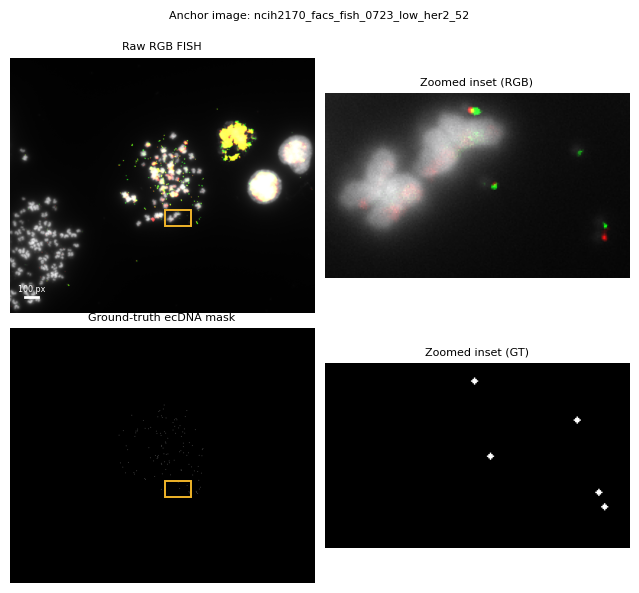

  Saved SVG: fig1_anchor_rgb_gt_with_zoom.svg
  Saved PNG: fig1_anchor_rgb_gt_with_zoom.png


In [11]:
# ── Fig 1F: Anchor image and zoomed inset (RGB + GS) ─────────────────────────
# Layout:
# [ raw RGB full ]   [ raw RGB inset ]
# [ GS full     ]   [ GS inset      ]

x0, y0, x1, y1 = ANCHOR_INSET_BBOX

# Crop images
crop_rgb = anchor_rgb[y0:y1, x0:x1]
crop_gt = anchor_gt_bin[y0:y1, x0:x1]

# Make a brighter GS display image for visibility
gt_full_vis = (anchor_gt_bin.astype(np.uint8) * 255)
gt_crop_vis = (crop_gt.astype(np.uint8) * 255)

fig, axes = plt.subplots(2, 2, figsize=(6.4, 5.8))

# ── Raw RGB full
axes[0, 0].imshow(anchor_rgb)
axes[0, 0].add_patch(Rectangle(
    (x0, y0), x1 - x0, y1 - y0,
    linewidth=1.4, edgecolor='#F0B429', facecolor='none'
))
axes[0, 0].set_title('Raw RGB FISH')
axes[0, 0].axis('off')

# Scale bar
sb_x, sb_y, sb_len = W * 0.05, H * 0.94, 100
axes[0, 0].plot([sb_x, sb_x + sb_len], [sb_y, sb_y], color='white', linewidth=2.0)
axes[0, 0].text(
    sb_x + sb_len / 2,
    sb_y - H * 0.015,
    '100 px',
    color='white',
    fontsize=5.8,
    ha='center',
    va='bottom'
)

# ── Raw RGB inset
axes[0, 1].imshow(crop_rgb)
axes[0, 1].set_title('Zoomed inset (RGB)')
axes[0, 1].axis('off')

# ── GS full
axes[1, 0].imshow(gt_full_vis, cmap='gray', vmin=0, vmax=255)
axes[1, 0].add_patch(Rectangle(
    (x0, y0), x1 - x0, y1 - y0,
    linewidth=1.4, edgecolor='#F0B429', facecolor='none'
))
axes[1, 0].set_title('Gold-standard ecDNA mask')
axes[1, 0].axis('off')

# ── GS inset
axes[1, 1].imshow(gt_crop_vis, cmap='gray', vmin=0, vmax=255)
axes[1, 1].set_title('Zoomed inset (GS)')
axes[1, 1].axis('off')

fig.suptitle(f'Anchor image: {ANCHOR_UID}', y=1.01, fontsize=8)

fig.tight_layout()

display(fig)

svg_path = OUT_DIR / 'fig1_anchor_rgb_gt_with_zoom.svg'
png_path = OUT_DIR / 'fig1_anchor_rgb_gt_with_zoom.png'
fig.savefig(svg_path, format='svg', bbox_inches='tight')
fig.savefig(png_path, format='png', dpi=300, bbox_inches='tight')

print(f'  Saved SVG: {svg_path.name}')
print(f'  Saved PNG: {png_path.name}')

plt.close(fig)

### Figure 1 panel — Anchor image: raw RGB and GS mask with zoom inset

A 2 × 2 grid showing:
- **Top-left:** the full raw RGB FISH image with the inset rectangle
  (orange box) marking the zoomed region.
- **Top-right:** the zoomed inset (RGB), magnifying the orange-boxed area.
- **Bottom-left:** the full gold-standard mask, showing all 116 ecDNA
  annotations as small white dots.
- **Bottom-right:** the zoomed GS mask inset.

The zoom region `[x0=1247, y0=1225, x1=1458, y1=1353]` (211 × 128 px)
was selected because it contains a small cluster of isolated ecDNA foci
at varying sizes, making the diamond-render structure clearly visible.

Saved as: `fig1_anchor_rgb_gt_with_zoom.svg`


---

## §5 — ROI mask and the masking process

The ROI mask defines the analysis region for each image.  All model
predictions and GS annotations are evaluated **only within the ROI**.
Pixels outside the ROI are excluded from every metric computation.

The masking procedure is a simple element-wise multiply: pixels outside
the ROI are set to zero in both the prediction mask and the GS mask
before matching and metric calculation.

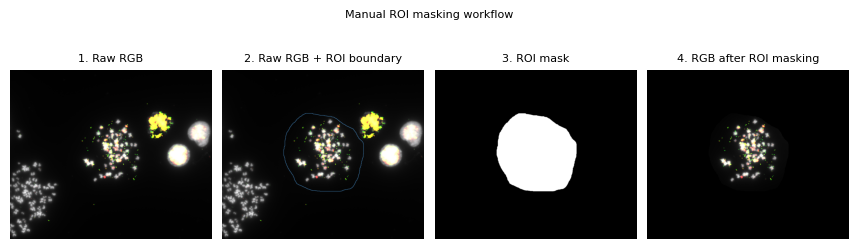

  Saved SVG: fig1_anchor_roi_masking_workflow.svg
  Saved PNG: fig1_anchor_roi_masking_workflow.png


In [12]:
# ── Fig 1G: Four-step ROI masking process ────────────────────────────────────
# Columns:
# 1. Raw RGB
# 2. Raw RGB + ROI boundary
# 3. ROI mask
# 4. RGB after ROI masking

def draw_mask_contours_on_rgb(rgb, mask, color=(90, 180, 255), thickness=2):
    """Draw binary-mask contours on an RGB image."""
    out = rgb.copy()
    contours, _ = cv2.findContours(
        mask.astype(np.uint8),
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )
    cv2.drawContours(out, contours, -1, color, thickness)
    return out

rgb_with_roi_outline = draw_mask_contours_on_rgb(anchor_rgb, anchor_roi_bin, color=(90, 180, 255), thickness=2)
roi_vis = (anchor_roi_bin.astype(np.uint8) * 255)

fig, axes = plt.subplots(1, 4, figsize=(8.6, 2.45))

panels = [
    (anchor_rgb, '1. Raw RGB'),
    (rgb_with_roi_outline, '2. Raw RGB + ROI boundary'),
    (roi_vis, '3. ROI mask'),
    (anchor_rgb_roi, '4. RGB after ROI masking'),
]

for ax, (img, title) in zip(axes, panels):
    if img.ndim == 2:
        ax.imshow(img, cmap='gray', vmin=0, vmax=255)
    else:
        ax.imshow(img)
    ax.set_title(title, pad=6)
    ax.axis('off')

fig.suptitle('Manual ROI masking workflow', y=1.05, fontsize=8)

fig.tight_layout()

display(fig)

svg_path = OUT_DIR / 'fig1_anchor_roi_masking_workflow.svg'
png_path = OUT_DIR / 'fig1_anchor_roi_masking_workflow.png'
fig.savefig(svg_path, format='svg', bbox_inches='tight')
fig.savefig(png_path, format='png', dpi=300, bbox_inches='tight')

print(f'  Saved SVG: {svg_path.name}')
print(f'  Saved PNG: {png_path.name}')

plt.close(fig)


### Figure 1 panel — Manual ROI masking workflow (four steps)

A four-panel strip illustrating the ROI masking pipeline step by step:
1. **Raw RGB** — the original fluorescence image (cropped for display).
2. **Raw RGB + ROI boundary** — the raw image with the manual ROI contour
   drawn in blue.
3. **ROI mask** — the binary mask itself (white = inside ROI, black = outside).
4. **RGB after ROI masking** — the image after zeroing pixels outside the
   ROI, i.e. what the model and evaluator "see."

Saved as: `fig1_anchor_roi_masking_workflow.svg`


---

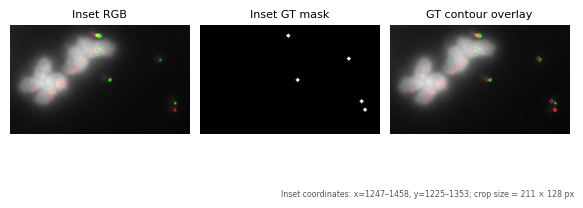

  Saved SVG: fig1_anchor_inset_clean.svg
  Saved PNG: fig1_anchor_inset_clean.png


In [13]:
# ── Fig 1H: Anchor inset — RGB, GS mask, and contour overlay ─────────────────
# Cleaner version without the repetitive "Inset RGB + ROI" panel.

x0, y0, x1, y1 = ANCHOR_INSET_BBOX

crop_rgb = anchor_rgb[y0:y1, x0:x1]
crop_gt = anchor_gt_bin[y0:y1, x0:x1]

crop_gt_vis = (crop_gt.astype(np.uint8) * 255)

# Contour overlay
crop_contours, _ = cv2.findContours(
    crop_gt.astype(np.uint8),
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

crop_contour_overlay = crop_rgb.copy()
cv2.drawContours(
    crop_contour_overlay,
    crop_contours,
    contourIdx=-1,
    color=(255, 70, 70),
    thickness=1
)

fig, axes = plt.subplots(1, 3, figsize=(5.8, 2.1))

panels = [
    (crop_rgb, 'Inset RGB'),
    (crop_gt_vis, 'Inset GS mask'),
    (crop_contour_overlay, 'GS contour overlay'),
]

for ax, (img, title) in zip(axes, panels):
    if img.ndim == 2:
        ax.imshow(img, cmap='gray', vmin=0, vmax=255)
    else:
        ax.imshow(img)
    ax.set_title(title, pad=6)
    ax.axis('off')

fig.text(
    0.99, -0.02,
    f'Inset coordinates: x={x0}–{x1}, y={y0}–{y1}; crop size = {x1-x0} × {y1-y0} px',
    ha='right',
    va='top',
    fontsize=5.7,
    color='0.35'
)

fig.tight_layout()

display(fig)

svg_path = OUT_DIR / 'fig1_anchor_inset_clean.svg'
png_path = OUT_DIR / 'fig1_anchor_inset_clean.png'
fig.savefig(svg_path, format='svg', bbox_inches='tight')
fig.savefig(png_path, format='png', dpi=300, bbox_inches='tight')

print(f'  Saved SVG: {svg_path.name}')
print(f'  Saved PNG: {png_path.name}')

plt.close(fig)


### Figure 1 panel — Zoomed inset: RGB, GS mask, and contour overlay

A three-panel close-up of the inset region, showing:
1. **Inset RGB** — the raw fluorescence crop.
2. **Inset GS mask** — the binary diamond mask for the same region; each
   bright spot is one GS connected component.
3. **GS contour overlay** — GS contours (red diamonds) drawn over the RGB,
   making it easy to see where each annotation sits relative to the
   fluorescence signal.

This panel is designed to explain the diamond-render representation: an
annotator places a point at each ecDNA focus, and the rendering step
converts it to a 7 × 7 diamond.  Two close diamonds that overlap merge
into a single CC — the *diamond-merge artifact* — which is why
`ecDNA_gt` can be slightly lower than `coord_count_npy`.

Saved as: `fig1_anchor_inset_clean.svg`


---

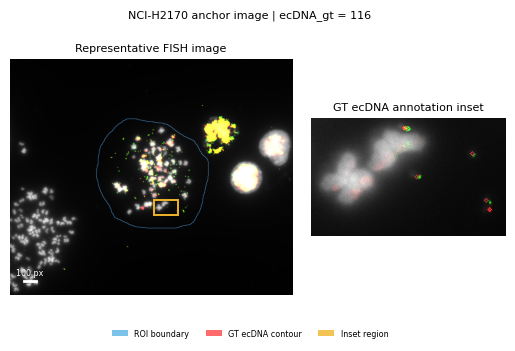

  Saved SVG: fig1_anchor_composite.svg
  Saved PNG: fig1_anchor_composite.png


In [14]:
# ── Fig 1H: Polished anchor composite panel ─────────────────────────────────
# Main-paper style panel:
# left = full RGB with ROI boundary and inset box
# right = zoomed inset with GS contour overlay

x0, y0, x1, y1 = ANCHOR_INSET_BBOX

crop_rgb = anchor_rgb[y0:y1, x0:x1]
crop_gt = anchor_gt_bin[y0:y1, x0:x1]

# Full image with ROI contour and inset rectangle
full_panel = anchor_rgb.copy()

roi_contours, _ = cv2.findContours(
    anchor_roi_bin.astype(np.uint8),
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

full_panel_with_roi = full_panel.copy()
cv2.drawContours(
    full_panel_with_roi,
    roi_contours,
    contourIdx=-1,
    color=(90, 180, 255),
    thickness=2
)

# Inset contour overlay
crop_contours, _ = cv2.findContours(
    crop_gt.astype(np.uint8),
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

crop_panel = crop_rgb.copy()
cv2.drawContours(
    crop_panel,
    crop_contours,
    contourIdx=-1,
    color=(255, 70, 70),
    thickness=1
)

fig = plt.figure(figsize=(6.4, 3.2))
gs = fig.add_gridspec(1, 2, width_ratios=[1.45, 1.0], wspace=0.08)

ax_full = fig.add_subplot(gs[0, 0])
ax_crop = fig.add_subplot(gs[0, 1])

ax_full.imshow(full_panel_with_roi)
ax_full.axis('off')
ax_full.set_title('Representative FISH image', pad=6)

rect = Rectangle(
    (x0, y0),
    x1 - x0,
    y1 - y0,
    linewidth=1.4,
    edgecolor='#F0B429',
    facecolor='none'
)
ax_full.add_patch(rect)

# Scale bar on full image
sb_x, sb_y, sb_len = W * 0.05, H * 0.94, 100
ax_full.plot([sb_x, sb_x + sb_len], [sb_y, sb_y], color='white', linewidth=2.0)
ax_full.text(
    sb_x + sb_len / 2,
    sb_y - H * 0.015,
    '100 px',
    color='white',
    fontsize=5.8,
    ha='center',
    va='bottom'
)

ax_crop.imshow(crop_panel)
ax_crop.axis('off')
ax_crop.set_title('GS ecDNA annotation inset', pad=6)

# Legend-like labels
legend_handles = [
    mpatches.Patch(facecolor='#5AB4E6', edgecolor='none', alpha=0.8, label='ROI boundary'),
    mpatches.Patch(facecolor='#FF4646', edgecolor='none', alpha=0.8, label='GS ecDNA contour'),
    mpatches.Patch(facecolor='#F0B429', edgecolor='none', alpha=0.8, label='Inset region'),
]

fig.legend(
    handles=legend_handles,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.03),
    ncol=3,
    frameon=False,
    fontsize=5.8
)

title = f'{canonical_cell_line(anchor_row.get("cell_line", ""))} anchor image'
if anchor_count is not None:
    title += f' | ecDNA_gt = {anchor_count:,}'

fig.suptitle(title, y=1.02, fontsize=8)

fig.tight_layout()

display(fig)

svg_path = OUT_DIR / 'fig1_anchor_composite.svg'
png_path = OUT_DIR / 'fig1_anchor_composite.png'
fig.savefig(svg_path, format='svg', bbox_inches='tight')
fig.savefig(png_path, format='png', dpi=300, bbox_inches='tight')

print(f'  Saved SVG: {svg_path.name}')
print(f'  Saved PNG: {png_path.name}')

plt.close(fig)

### Figure 1 panel — Main-paper anchor composite (Figure 1A equivalent)

This is the polished two-panel figure intended for the main paper:
- **Left:** the full RGB FISH image at reduced scale, with the ROI boundary
  drawn in blue and the inset rectangle in orange.  A 100 px scale bar is
  placed in the lower-left corner.
- **Right:** the zoomed inset with GS ecDNA contours (red) overlaid on the
  RGB, showing individual foci at high magnification.

A legend at the bottom identifies the three overlaid elements:
ROI boundary (blue), GS ecDNA contour (red), and Inset region (orange).

The figure title reports the cell line and `ecDNA_gt` count for the
anchor image (`NCI-H2170 anchor image | ecDNA_gt = 116`).

Saved as: `fig1_anchor_composite.svg`


---

## §6 — Gold-standard count verification

This is a **diagnostic cell**, not a figure cell.

It independently recomputes the ecDNA count for the anchor image directly
from the loaded GS mask, and cross-checks it against the value stored in
`counts_master.csv`.

**How `ecDNA_gt` is computed:**
1. Binarise the GS mask (`> 0`).
2. Label 8-connected components (`skimage.measure.label`, `connectivity=2`).
3. Filter to components with area ≥ 3 px.
4. Count the surviving components.

For the anchor image the result is:
- Total CCs (any area): 116
- CCs with min area 3 px: 116
- `ecDNA_gt` from `counts_master.csv`: 116 ✓

The cell also saves a source CSV (`source_anchor_gt_connected_components.csv`)
with the centroid coordinates and area of every GS component, providing full
transparency.

---

In [15]:
# ── Anchor GS connected-component QC ─────────────────────────────────────────
# This is a diagnostic cell, not a figure cell.
# It verifies how the anchor ecDNA count is obtained from the rendered GS mask.

from skimage.measure import label as sk_label, regionprops

gt_labeled = sk_label(anchor_gt_bin, connectivity=2)  # connectivity=2 means 8-connectivity in 2D
props = regionprops(gt_labeled)

gt_cc_any_area = len(props)
gt_cc_min3 = sum(p.area >= 3 for p in props)

print('Anchor GS connected-component summary:')
print(f'  GS CCs, 8-connectivity, any area: {gt_cc_any_area:,}')
print(f'  GS CCs, 8-connectivity, min area 3 px: {gt_cc_min3:,}')

if anchor_count is not None:
    print(f'  ecDNA_gt from counts_master.csv: {anchor_count:,}')
    print(f'  Matches min-area-3 CC count: {anchor_count == gt_cc_min3}')

# Save anchor centroid source data for transparency
centroids_min3 = np.array([
    [p.centroid[0], p.centroid[1], p.area]
    for p in props
    if p.area >= 3
])

anchor_cc_csv = OUT_DIR / 'source_anchor_gt_connected_components.csv'

if len(centroids_min3) > 0:
    pd.DataFrame(
        centroids_min3,
        columns=['cy', 'cx', 'area_px']
    ).to_csv(anchor_cc_csv, index=False)
else:
    pd.DataFrame(columns=['cy', 'cx', 'area_px']).to_csv(anchor_cc_csv, index=False)

print(f'  Saved source table: {anchor_cc_csv.name}')

Anchor GT connected-component summary:
  GT CCs, 8-connectivity, any area: 116
  GT CCs, 8-connectivity, min area 3 px: 116
  ecDNA_gt from counts_master.csv: 116
  Matches min-area-3 CC count: True
  Saved source table: source_anchor_gt_connected_components.csv


## Summary

This notebook has produced the following files in `release/figures/notebook01/`:

**Figure panels (SVG + PNG):**
- `fig1_resource_composition_horizontal` — §1 full resource vs benchmark
- `fig1_split_heatmap` — §2 train/val/test by cell line
- `fig1_count_distribution` — §3 ecDNA count histogram
- `fig1_count_by_cell_line_boxstrip` — §3 per-cell-line count distributions
- `fig1_density_composition_heatmap` — §3 density-bin composition
- `fig1_anchor_rgb_gt_with_zoom` — §4 anchor RGB + GS with inset
- `fig1_anchor_roi_masking_workflow` — §5 ROI masking four-step strip
- `fig1_anchor_inset_clean` — §5 zoomed inset with contour overlay
- `fig1_anchor_composite` — §4+5 combined main-paper panel

**Source-data CSVs:**
- `source_full_resource_summary.csv`
- `source_benchmark_count_summary.csv`
- `source_density_bin_summary.csv`
- `source_global_count_summary.csv`
- `fig1_density_composition_counts.csv`
- `fig1_density_composition_percent.csv`
- `source_anchor_gt_connected_components.csv`

**Next:** open `02_classical_pipeline.ipynb` to see how the classical
pipeline works and how Bayesian optimisation improved it per cell line.
